<a href="https://colab.research.google.com/github/rahilkhan-acadmic/APAIML-GradedMiniProject/blob/develop/capstone/02_risk_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model A — Visit Risk Classification
### Business Purpose: Predict whether a hospital visit represents a Low, Medium, or High operational and clinical risk.

   * Define the target variable as risk_score.
   *  Select and justify feature set based on business relevance.
   *  Perform a time-based train and test split (earliest 80 percent for training, latest 20 percent for testing).
   *  Train a baseline model using Logistic Regression.
   *  Train an advanced model such as Random Forest or Gradient Boosting.
   *  Perform optional hyperparameter tuning and document results.

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [96]:
# Upload file to google.colab
import io
from google.colab import files, drive

drive.mount('/content/drive')

# comment this code, if files already uploaded.
# uploaded = files.upload()

# Load and read patients, visits & billing csv
patients_df = pd.read_csv('/content/drive/MyDrive/files/capstone/patients.csv')
# patients_df.head()

visits_df = pd.read_csv('/content/drive/MyDrive/files/capstone/visits.csv')
# visits_df.head()

billing_df = pd.read_csv('/content/drive/MyDrive/files/capstone/billing.csv')
# billing_df.head()

# Merge dataframe
df_merged = pd.merge(patients_df, visits_df, on='patient_id', how = 'inner')
df_merged = pd.merge(df_merged, billing_df, on='visit_id', how = 'inner')
df_merged.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,1,53,M,Hyderabad,SecureLife,0,2025-05-14,4327,2025-10-15,General,ICU,6.39,High,162,4327,26322.05,13938.52,Pending,NaN,2025-11-29
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,OPD,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,OPD,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,ER,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,ER,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26


### Define the target variable as risk_score_encoded.

In [97]:
# Define the target variable as risk_score.
df_target = df_merged[['risk_score']]
display(df_target.head().reset_index())


,index,risk_score
0,0,High
1,1,Low
2,2,Medium
3,3,Medium
4,4,High


### Feature Engineering

In [98]:
# Engineer date columns

# Convert Date Columns to datetime objects.
date_columns = ['registration_date', 'visit_date', 'billing_date']
for col in date_columns:
    df_merged[col] = pd.to_datetime(df_merged[col])

# Display the data types to verify the conversion
print(df_merged[['registration_date', 'visit_date', 'billing_date']].dtypes)

# Sorting df_merged based on patient_id, registration_date, visit_date, billing_date
df_merged = df_merged.sort_values(by=['patient_id', 'registration_date', 'visit_date', 'billing_date'])

display(df_merged)

registration_date    datetime64[ns]
visit_date           datetime64[ns]
billing_date         datetime64[ns]
dtype: object


,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
2,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9032,2025-02-09,Cardiology,OPD,19.57,Medium,121,9032,26555.09,26555.09,Paid,4.0,2025-12-31
5,1,53,M,Hyderabad,SecureLife,0,2025-05-14,23957,2025-07-05,Orthopedics,ER,7.63,Medium,178,23957,38801.14,38801.14,Paid,1.0,2025-09-27
4,1,53,M,Hyderabad,SecureLife,0,2025-05-14,10868,2025-07-07,ICU,ER,30.07,High,164,10868,9049.72,9049.72,Paid,19.0,2025-02-26
1,1,53,M,Hyderabad,SecureLife,0,2025-05-14,5395,2025-09-21,Orthopedics,OPD,39.12,Low,181,5395,13258.56,0.00,Rejected,3.0,2025-08-15
3,1,53,M,Hyderabad,SecureLife,0,2025-05-14,9506,2025-10-09,Neurology,ER,30.32,Medium,135,9506,11583.16,8065.34,Pending,6.0,2025-01-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24998,5000,29,M,Chennai,MediCareX,0,2025-07-29,23879,2025-02-17,General,ICU,13.71,Low,162,23879,11029.37,8322.08,Pending,23.0,2026-01-18
24995,5000,29,M,Chennai,MediCareX,0,2025-07-29,14756,2025-03-24,ICU,ER,8.52,Low,123,14756,29171.44,21865.80,Pending,1.0,2025-03-30
24999,5000,29,M,Chennai,MediCareX,0,2025-07-29,24588,2025-06-17,Neurology,ICU,22.93,Medium,165,24588,19004.72,16184.24,Pending,23.0,2025-06-12
24997,5000,29,M,Chennai,MediCareX,0,2025-07-29,20692,2025-11-20,Orthopedics,ER,33.39,Low,167,20692,13825.80,13825.80,Paid,7.0,2025-08-14


In [99]:
# Engineer Financial Features

# 1. Create 'amount_difference'
df_merged['amount_difference'] = df_merged['billed_amount'] - df_merged['approved_amount']

# 2. Create 'approval_ratio', handling division by zero
df_merged['approval_ratio'] = np.where(
    df_merged['billed_amount'] != 0,
    df_merged['approved_amount'] / df_merged['billed_amount'],
    0  # Assign 0 if billed_amount is zero to avoid division by zero
)

# Display the head of df_merged with new columns to verify
print(df_merged[['billed_amount', 'approved_amount', 'amount_difference', 'approval_ratio']].head())

   billed_amount  approved_amount  amount_difference  approval_ratio
2       26555.09         26555.09               0.00        1.000000
5       38801.14         38801.14               0.00        1.000000
4        9049.72          9049.72               0.00        1.000000
1       13258.56             0.00           13258.56        0.000000
3       11583.16          8065.34            3517.82        0.696299


In [100]:
# Engineering Time-Based Operational Features
df_merged['days_since_registration_to_visit'] = (df_merged['visit_date'] - df_merged['registration_date']).dt.days
df_merged['days_between_visit_and_billing'] = (df_merged['billing_date'] - df_merged['visit_date']).dt.days
df_merged['length_of_stay_days'] = df_merged['length_of_stay_hours'] / 24

# Display the head of df_merged with new columns to verify
display(df_merged[['registration_date', 'visit_date', 'billing_date', 'days_since_registration_to_visit', 'days_between_visit_and_billing', 'length_of_stay_hours', 'length_of_stay_days']].head())

# Handling days_between_visit_and_billing with -ve value.
# This could be due to data inconsistency or pre-approval case.
# For such cases -ve values are replaced with 0
df_merged['days_between_visit_and_billing'] = df_merged['days_between_visit_and_billing'].apply(lambda x: max(0, x))

print("df_merged with corrected 'days_between_visit_and_billing' (negative values set to 0):")
display(df_merged[['patient_id', 'visit_date', 'billing_date', 'days_between_visit_and_billing']].head())

,registration_date,visit_date,billing_date,days_since_registration_to_visit,days_between_visit_and_billing,length_of_stay_hours,length_of_stay_days
2,2025-05-14,2025-02-09,2025-12-31,-94,325,19.57,0.815417
5,2025-05-14,2025-07-05,2025-09-27,52,84,7.63,0.317917
4,2025-05-14,2025-07-07,2025-02-26,54,-131,30.07,1.252917
1,2025-05-14,2025-09-21,2025-08-15,130,-37,39.12,1.630000
3,2025-05-14,2025-10-09,2025-01-30,148,-252,30.32,1.263333


df_merged with corrected 'days_between_visit_and_billing' (negative values set to 0):


,patient_id,visit_date,billing_date,days_between_visit_and_billing
2,1,2025-02-09,2025-12-31,325
5,1,2025-07-05,2025-09-27,84
4,1,2025-07-07,2025-02-26,0
1,1,2025-09-21,2025-08-15,0
3,1,2025-10-09,2025-01-30,0


### Select and justify feature set based on business relevance.

In [101]:
# Select and justify feature set based on business relevance.
# 'patient_id' not dropped as it will be used for grouping and sorting later
df_features = df_merged.drop(columns=['risk_score', 'visit_id','bill_id', 'doctor_id'])

# One-Hot Encoding for Categorical Features
categorical_cols = ['gender', 'city', 'insurance_provider', 'department', 'visit_type']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_merged[categorical_cols], columns=categorical_cols, drop_first=True)

display(df_features.columns)

# Drop original categorical columns from df_features, ignoring errors if columns are already absent
df_features = df_features.drop(columns=categorical_cols, errors='ignore')
# Concatenate the one-hot encoded features with df_features
df_features = pd.concat([df_features, df_encoded], axis=1)

print("Shape of df_features after one-hot encoding:", df_features.shape)
print("Head of df_features after one-hot encoding:")
display(df_features.head())


Index(['patient_id', 'age', 'gender', 'city', 'insurance_provider',
       'chronic_flag', 'registration_date', 'visit_date', 'department',
       'visit_type', 'length_of_stay_hours', 'billed_amount',
       'approved_amount', 'claim_status', 'payment_days', 'billing_date',
       'amount_difference', 'approval_ratio',
       'days_since_registration_to_visit', 'days_between_visit_and_billing',
       'length_of_stay_days'],
      dtype='object')

Shape of df_features after one-hot encoding: (25000, 32)
Head of df_features after one-hot encoding:


,patient_id,age,chronic_flag,registration_date,visit_date,length_of_stay_hours,billed_amount,approved_amount,claim_status,payment_days,...,insurance_provider_HealthPlus,insurance_provider_MediCareX,insurance_provider_SecureLife,department_ER,department_General,department_ICU,department_Neurology,department_Orthopedics,visit_type_ICU,visit_type_OPD
2,1,53,0,2025-05-14,2025-02-09,19.57,26555.09,26555.09,Paid,4.0,...,False,False,True,False,False,False,False,False,False,True
5,1,53,0,2025-05-14,2025-07-05,7.63,38801.14,38801.14,Paid,1.0,...,False,False,True,False,False,False,False,True,False,False
4,1,53,0,2025-05-14,2025-07-07,30.07,9049.72,9049.72,Paid,19.0,...,False,False,True,False,False,True,False,False,False,False
1,1,53,0,2025-05-14,2025-09-21,39.12,13258.56,0.00,Rejected,3.0,...,False,False,True,False,False,False,False,True,False,True
3,1,53,0,2025-05-14,2025-10-09,30.32,11583.16,8065.34,Pending,6.0,...,False,False,True,False,False,False,True,False,False,False


In [102]:
# apply data engineering on df_features
# Create a fresh df_features DataFrame by explicitly selecting desired columns
# Start with numerical columns that are definitely needed and not redundant from df_merged
initial_numerical_cols = [
    'patient_id', 'age', 'chronic_flag',
    'billed_amount', 'approved_amount', 'payment_days'
]

df_features = df_merged[initial_numerical_cols].copy()

# Add the engineered financial and operational features that are already calculated in df_merged
engineered_cols_from_merged = [
    'amount_difference', 'approval_ratio',
    'days_between_visit_and_billing', 'length_of_stay_days'
]

display(df_features.columns)

for col in engineered_cols_from_merged:
    if col in df_merged.columns and col not in df_features.columns:
        df_features[col] = df_merged[col]

# Concatenate the one-hot encoded categorical features
df_features = pd.concat([df_features, df_encoded], axis=1)

# Calculate days between visits for each patient and then the average
df_merged_sorted = df_merged.sort_values(by=['patient_id', 'visit_date'])
df_merged_sorted['days_between_visits'] = df_merged_sorted.groupby('patient_id')['visit_date'].diff().dt.days
df_avg_days_between_visits = df_merged_sorted.groupby('patient_id')['days_between_visits'].mean().reset_index()
df_avg_days_between_visits.rename(columns={'days_between_visits': 'avg_days_between_visits'}, inplace=True)

# Merge this new feature into df_features
df_features = pd.merge(df_features, df_avg_days_between_visits, on='patient_id', how='left')

# Final clean-up: Remove the target variable and the less relevant time feature
columns_to_drop_final = [
    'risk_score', # Target variable, must not be in features
    'days_since_registration_to_visit' # Replaced by avg_days_between_visits as per user feedback
]
df_features = df_features.drop(columns=columns_to_drop_final, errors='ignore')

# Display .info() of the updated df_features
print("\nInfo of df_features after integrating new features and dropping redundant columns:")
df_features.info()

# Display .head() of the updated df_features
print("\nHead of df_features after integrating new features and dropping redundant columns:")
display(df_features.head())

# Display .info() of the updated df_features
print("\nInfo of df_features after integrating new features and dropping redundant columns:")
df_features.info()



Index(['patient_id', 'age', 'chronic_flag', 'billed_amount', 'approved_amount',
       'payment_days'],
      dtype='object')


Info of df_features after integrating new features and dropping redundant columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      25000 non-null  int64  
 1   age                             25000 non-null  int64  
 2   chronic_flag                    25000 non-null  int64  
 3   billed_amount                   25000 non-null  float64
 4   approved_amount                 23682 non-null  float64
 5   payment_days                    24210 non-null  float64
 6   amount_difference               23682 non-null  float64
 7   approval_ratio                  23682 non-null  float64
 8   days_between_visit_and_billing  25000 non-null  int64  
 9   length_of_stay_days             25000 non-null  float64
 10  gender_M                        25000 non-null  bool   
 11  city_Chen

,patient_id,age,chronic_flag,billed_amount,approved_amount,payment_days,amount_difference,approval_ratio,days_between_visit_and_billing,length_of_stay_days,...,insurance_provider_MediCareX,insurance_provider_SecureLife,department_ER,department_General,department_ICU,department_Neurology,department_Orthopedics,visit_type_ICU,visit_type_OPD,avg_days_between_visits
0,1,53,0,26555.09,26555.09,4.0,0.00,1.000000,325,0.815417,...,False,True,False,False,False,False,False,False,True,49.6
1,1,53,0,38801.14,38801.14,1.0,0.00,1.000000,84,0.317917,...,False,True,False,False,False,False,True,False,False,49.6
2,1,53,0,9049.72,9049.72,19.0,0.00,1.000000,0,1.252917,...,False,True,False,False,True,False,False,False,False,49.6
3,1,53,0,13258.56,0.00,3.0,13258.56,0.000000,0,1.630000,...,False,True,False,False,False,False,True,False,True,49.6
4,1,53,0,11583.16,8065.34,6.0,3517.82,0.696299,0,1.263333,...,False,True,False,False,False,True,False,False,False,49.6



Info of df_features after integrating new features and dropping redundant columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      25000 non-null  int64  
 1   age                             25000 non-null  int64  
 2   chronic_flag                    25000 non-null  int64  
 3   billed_amount                   25000 non-null  float64
 4   approved_amount                 23682 non-null  float64
 5   payment_days                    24210 non-null  float64
 6   amount_difference               23682 non-null  float64
 7   approval_ratio                  23682 non-null  float64
 8   days_between_visit_and_billing  25000 non-null  int64  
 9   length_of_stay_days             25000 non-null  float64
 10  gender_M                        25000 non-null  bool   
 11  city_Chen

### Perform a time-based train and test split (earliest 80 percent for training, latest 20 percent for testing).

Value counts of 'risk_score' in the training set:
risk_score
Low       9962
Medium    6043
High      3995
Name: count, dtype: int64


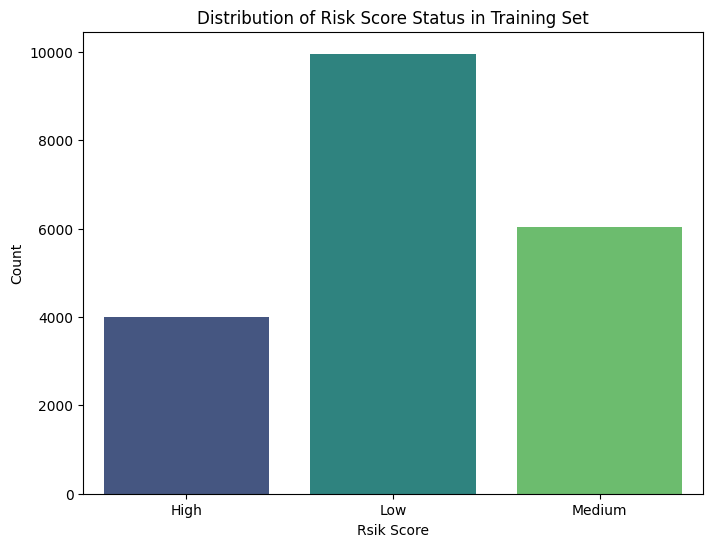

In [104]:
# Perform a time-based train and test split (earliest 80 percent for training, latest 20 percent for testing).
train_X,test_x, train_y, test_y = train_test_split(df_features, df_target, test_size=0.2, shuffle=False)

print("Value counts of 'risk_score' in the training set:")
print(train_y['risk_score'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=train_y, x='risk_score', hue='risk_score', palette='viridis', legend=False)
plt.title('Distribution of Risk Score Status in Training Set')
plt.xlabel('Rsik Score')
plt.ylabel('Count')
plt.show()

In [105]:
# Encode the categorical target variable 'claim_status' into numerical format using `LabelEncoder` for both `train_y` and `test_y`.
# Instantiate LabelEncoder
le = LabelEncoder()

# Fit LabelEncoder to the full df_target to ensure all categories are learned
# This avoids errors if some categories are present in test_y but not train_y
le.fit(df_target['risk_score'])

# Transform the 'claim_status' column in train_y
train_y['risk_score_encoded'] = le.transform(train_y['risk_score'])

# Transform the 'claim_status' column in test_y
test_y['risk_score_encoded'] = le.transform(test_y['risk_score'])

# Display the head of the transformed train_y and test_y to verify the encoding
print("Head of transformed train_y:")
display(train_y.head())

print("Head of transformed test_y:")
display(test_y.head())

print("Mapping of encoded classes:")
for i, class_name in enumerate(le.classes_):
    print(f"{class_name}: {i}")

Head of transformed train_y:


,risk_score,risk_score_encoded
0,High,0
1,Low,1
2,Medium,2
3,Medium,2
4,High,0


Head of transformed test_y:


,risk_score,risk_score_encoded
20000,Low,1
20001,Low,1
20002,High,0
20003,Low,1
20004,High,0


Mapping of encoded classes:
High: 0
Low: 1
Medium: 2


In [106]:
# Address any remaining missing values in the feature DataFrames (`train_X` and `test_x`),
# specifically for columns like 'approved_amount', 'payment_days', and 'avg_days_between_visits'.
# Identify columns with missing values in train_X
missing_cols_train = train_X.isnull().sum()
missing_cols_train = missing_cols_train[missing_cols_train > 0].index.tolist()
print(f"Columns with missing values in train_X: {missing_cols_train}")

# Identify columns with missing values in test_x
missing_cols_test = test_x.isnull().sum()
missing_cols_test = missing_cols_test[missing_cols_test > 0].index.tolist()
print(f"Columns with missing values in test_x: {missing_cols_test}")

# Columns to impute (based on common missing ones and potential for others)
impute_cols = list(set(missing_cols_train + missing_cols_test))

# Calculate medians from train_X for imputation
imputation_values = {}
for col in impute_cols:
    if col in train_X.columns and train_X[col].dtype in ['float64', 'int64']:
        median_val = train_X[col].median()
        imputation_values[col] = median_val
        # Fix for FutureWarning: Avoid chained assignment by direct assignment
        train_X.loc[:, col] = train_X[col].fillna(median_val)
        test_x.loc[:, col] = test_x[col].fillna(median_val)
print(f"Imputation values (medians from train_X): {imputation_values}")

# Remove 'patient_id' column
if 'patient_id' in train_X.columns:
    train_X = train_X.drop(columns=['patient_id'])
    print("Dropped 'patient_id' from train_X")
if 'patient_id' in test_x.columns:
    test_x = test_x.drop(columns=['patient_id'])
    print("Dropped 'patient_id' from test_x")

# Verify no remaining missing values and 'patient_id' is dropped
print("\nMissing values after imputation in train_X:\n", train_X.isnull().sum().sum())
print("\nMissing values after imputation in test_x:\n", test_x.isnull().sum().sum())
print("\n'patient_id' in train_X columns:", 'patient_id' in train_X.columns)
print("'patient_id' in test_x columns:", 'patient_id' in test_x.columns)

print("\nHead of train_X after processing:")
display(train_X.head())
print("\nHead of test_x after processing:")
display(test_x.head())

Columns with missing values in train_X: ['approved_amount', 'payment_days', 'amount_difference', 'approval_ratio', 'avg_days_between_visits']
Columns with missing values in test_x: ['approved_amount', 'payment_days', 'amount_difference', 'approval_ratio', 'avg_days_between_visits']
Imputation values (medians from train_X): {'approved_amount': 14379.99, 'approval_ratio': 1.0, 'amount_difference': 0.0, 'avg_days_between_visits': 50.833333333333336, 'payment_days': 13.0}
Dropped 'patient_id' from train_X
Dropped 'patient_id' from test_x

Missing values after imputation in train_X:
 0

Missing values after imputation in test_x:
 0

'patient_id' in train_X columns: False
'patient_id' in test_x columns: False

Head of train_X after processing:


,age,chronic_flag,billed_amount,approved_amount,payment_days,amount_difference,approval_ratio,days_between_visit_and_billing,length_of_stay_days,gender_M,...,insurance_provider_MediCareX,insurance_provider_SecureLife,department_ER,department_General,department_ICU,department_Neurology,department_Orthopedics,visit_type_ICU,visit_type_OPD,avg_days_between_visits
0,53,0,26555.09,26555.09,4.0,0.00,1.000000,325,0.815417,True,...,False,True,False,False,False,False,False,False,True,49.6
1,53,0,38801.14,38801.14,1.0,0.00,1.000000,84,0.317917,True,...,False,True,False,False,False,False,True,False,False,49.6
2,53,0,9049.72,9049.72,19.0,0.00,1.000000,0,1.252917,True,...,False,True,False,False,True,False,False,False,False,49.6
3,53,0,13258.56,0.00,3.0,13258.56,0.000000,0,1.630000,True,...,False,True,False,False,False,False,True,False,True,49.6
4,53,0,11583.16,8065.34,6.0,3517.82,0.696299,0,1.263333,True,...,False,True,False,False,False,True,False,False,False,49.6



Head of test_x after processing:


,age,chronic_flag,billed_amount,approved_amount,payment_days,amount_difference,approval_ratio,days_between_visit_and_billing,length_of_stay_days,gender_M,...,insurance_provider_MediCareX,insurance_provider_SecureLife,department_ER,department_General,department_ICU,department_Neurology,department_Orthopedics,visit_type_ICU,visit_type_OPD,avg_days_between_visits
20000,43,0,44408.40,44408.40,7.0,0.0,1.0,0,0.746667,True,...,False,True,False,False,False,False,True,False,True,92.000000
20001,43,0,47069.41,47069.41,5.0,0.0,1.0,24,0.535417,True,...,False,True,False,False,False,True,False,False,False,92.000000
20002,84,1,6080.81,6080.81,4.0,0.0,1.0,62,0.744167,False,...,False,False,False,True,False,False,False,False,True,49.285714
20003,84,1,33919.66,33919.66,16.0,0.0,1.0,0,0.245833,False,...,False,False,False,False,False,False,True,False,True,49.285714
20004,84,1,26258.60,26258.60,13.0,0.0,1.0,266,0.717083,False,...,False,False,False,False,False,True,False,False,True,49.285714


### Analyze class imbalance and mitigation strategy.

In [107]:
# Performing class imbalance and mitigation beforehand to streamline process and model convergence.
import warnings
warnings.filterwarnings('ignore')

# Utilizing SMOTE to address class imabalance and its mitigation
# Import SMOTE
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_resampled, y_resampled = smote.fit_resample(train_X, train_y['risk_score_encoded'])

# Display the value counts of the resampled target to show the new class distribution
print("Class distribution after SMOTE:")
print(y_resampled.value_counts())


Class distribution after SMOTE:
risk_score_encoded
0    9962
1    9962
2    9962
Name: count, dtype: int64


### Train baseline and advanced classification models.

#### Following models are used for training
* Logistic Regression
* Random Forest

#### To analyze result, following techniques are used:
* Classication Report
* Confusion Matrix


Logistic Regression model trained successfully on resampled data with balanced class weights.

Classification Report for Logistic Regression Model:
              precision    recall  f1-score   support

        High       0.20      0.35      0.26      1039
         Low       0.49      0.35      0.41      2508
      Medium       0.29      0.28      0.28      1453

    accuracy                           0.33      5000
   macro avg       0.33      0.33      0.32      5000
weighted avg       0.37      0.33      0.34      5000



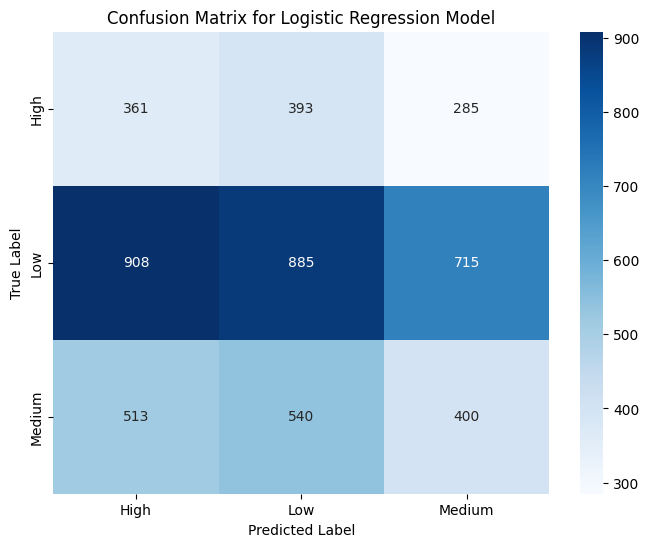

In [108]:
# Applying LogisticRegression

# Instantiate Logistic Regression model with class_weight='balanced'
log_reg_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

# Fit the model to the resampled training data
log_reg_model.fit(X_resampled, y_resampled)

print("Logistic Regression model trained successfully on resampled data with balanced class weights.")

# Model Evaluation
# 1. Use the trained log_reg_model to make predictions on the test_x features
y_pred_log_reg = log_reg_model.predict(test_x)

# 2. Generate a classification report
print("\nClassification Report for Logistic Regression Model:")
print(classification_report(test_y['risk_score_encoded'], y_pred_log_reg, target_names=le.classes_))

# 3. Create a confusion matrix
cm_log_reg = confusion_matrix(test_y['risk_score_encoded'], y_pred_log_reg)

# 4. Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()


### Train a Random Forest Classifier on the balanced training data.

Random Forest Classifier trained successfully on resampled data.

Classification Report for Random Forest Model:
              precision    recall  f1-score   support

        High       0.24      0.10      0.14      1039
         Low       0.50      0.74      0.60      2508
      Medium       0.30      0.18      0.23      1453

    accuracy                           0.45      5000
   macro avg       0.35      0.34      0.32      5000
weighted avg       0.39      0.45      0.40      5000



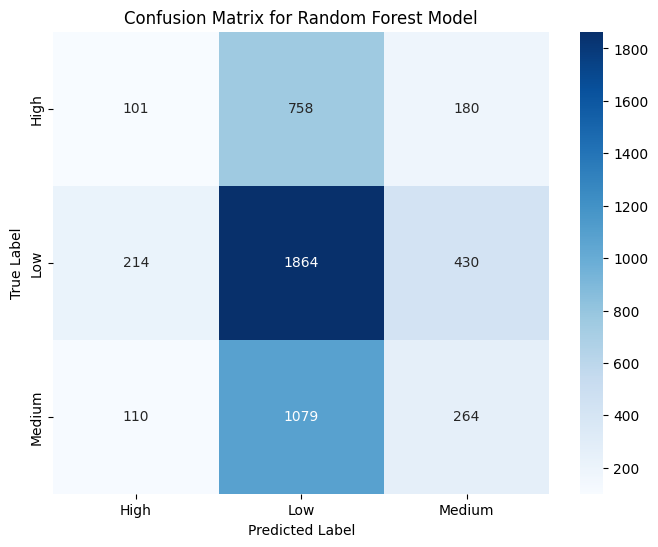

In [109]:
# Instantiate a RandomForestClassifier object
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the Random Forest model to the resampled training data
rf_model.fit(X_resampled, y_resampled)

print("Random Forest Classifier trained successfully on resampled data.")

# Make predictions on the test data using the trained Random Forest model
y_pred_rf = rf_model.predict(test_x)

# Generate a classification report
print("\nClassification Report for Random Forest Model:")
print(classification_report(test_y['risk_score_encoded'], y_pred_rf, target_names=le.classes_))

# Create a confusion matrix
cm_rf = confusion_matrix(test_y['risk_score_encoded'], y_pred_rf)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

#### Optional Hyperparameter Tuning for Random Forest
* Perform hyperparameter tuning for the Random Forest Classifier to optimize its performance.
* Perform hyperparameter tuning using `RandomizedSearchCV`

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters for Random Forest: {'criterion': 'gini', 'max_depth': 17, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 185}

Classification Report for Best Tuned Random Forest Model:
              precision    recall  f1-score   support

        High       0.21      0.07      0.10      1039
         Low       0.50      0.82      0.62      2508
      Medium       0.29      0.11      0.16      1453

    accuracy                           0.46      5000
   macro avg       0.34      0.33      0.30      5000
weighted avg       0.38      0.46      0.38      5000



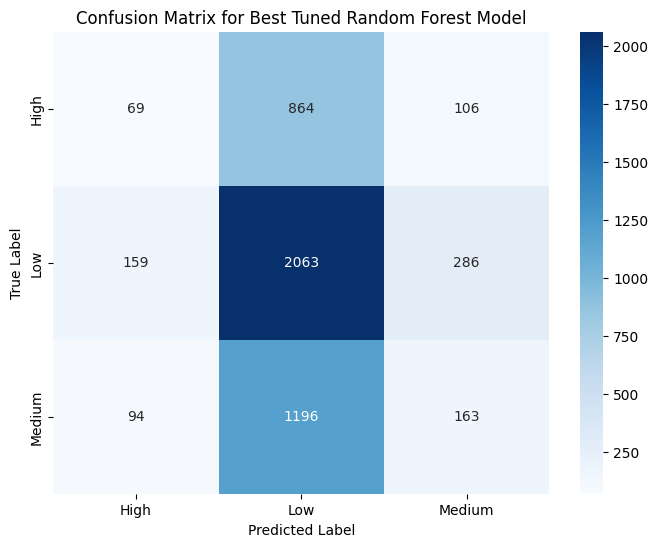

In [110]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 200),
    'max_features': ['sqrt', 'log2'],
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}

# Initialize a Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings that are sampled
    cv=3,       # Number of folds in cross-validation
    verbose=2,  # Controls the verbosity: the higher, the more messages
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit RandomizedSearchCV to the scaled training data
random_search.fit(X_resampled, y_resampled)

# Print the best parameters found
print("Best parameters for Random Forest:", random_search.best_params_)

# Get the best model
best_rf_model = random_search.best_estimator_

# Evaluate the best Random Forest model found by RandomizedSearchCV
y_pred_best_rf = best_rf_model.predict(test_x)

# Generate a classification report
print("\nClassification Report for Best Tuned Random Forest Model:")
print(classification_report(test_y['risk_score_encoded'], y_pred_best_rf, target_names=le.classes_))

# Create a confusion matrix
cm_best_rf = confusion_matrix(test_y['risk_score_encoded'], y_pred_best_rf)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Tuned Random Forest Model')
plt.show()

## Summary

### Steps Performed:

1.  **Data Loading and Merging**: Loaded three datasets (`patients.csv`, `visits.csv`, and `billing.csv`) and merged them into a single DataFrame, `df_merged`, based on common identifiers.
2.  **Target Variable Definition**: The `risk_score` column from the `df_merged` DataFrame was identified as the target variable.
3.  **Feature Engineering**: Several new features were created:
    *   Date columns (`registration_date`, `visit_date`, `billing_date`) were converted to datetime objects.
    *   Financial features like `amount_difference` (billed minus approved) and `approval_ratio` were calculated.
    *   Time-based operational features such as `days_since_registration_to_visit`, `days_between_visit_and_billing`, and `length_of_stay_days` were derived.
    *   Categorical features (`gender`, `city`, `insurance_provider`, `department`, `visit_type`) were transformed using one-hot encoding.
    *   `avg_days_between_visits` was calculated for each patient to capture visit frequency.
4.  **Train-Test Split**: A time-based split was performed, using the earliest 80% of the data for training and the latest 20% for testing, to simulate real-world prediction scenarios.
5.  **Target Encoding**: The categorical `risk_score` (High, Low, Medium) was encoded into numerical format (0, 1, 2) using `LabelEncoder` for model compatibility.
6.  **Missing Value Imputation**: Missing values in numerical features such as `approved_amount`, `payment_days`, `amount_difference`, `approval_ratio`, and `avg_days_between_visits` were imputed using the median values calculated from the training set.
7.  **Class Imbalance Mitigation**: SMOTE (Synthetic Minority Over-sampling Technique) was applied to the training data to address class imbalance in the `risk_score` target variable, creating a balanced dataset for training.
8.  **Model Training (Baseline)**: A Logistic Regression model was trained on the SMOTE-resampled training data.
9.  **Model Training (Advanced)**: A Random Forest Classifier was trained on the SMOTE-resampled training data.
10. **Hyperparameter Tuning**: `RandomizedSearchCV` was utilized to perform hyperparameter tuning for the Random Forest Classifier, searching for an optimal set of parameters to improve its performance.
11. **Model Evaluation**: Both the Logistic Regression and Random Forest models (including the best-tuned version) were evaluated using classification reports and confusion matrices to assess their precision, recall, F1-score, and overall accuracy on the unseen test data.

### Assumptions Made:

*   The temporal order of the data is critical and should be preserved in the train-test split.
*   Median imputation is a suitable strategy for handling missing numerical values in the selected features.
*   SMOTE is an effective technique to mitigate class imbalance and improve model learning for all risk categories.
*   The engineered features are relevant and contribute meaningfully to predicting the `risk_score`.

### Results Achieved:

*   **Data Preparation**: The data was successfully loaded, merged, cleaned, and transformed, resulting in a comprehensive feature set and an encoded target variable ready for modeling.
*   **Class Imbalance Handling**: SMOTE effectively balanced the `risk_score` classes in the training data, ensuring each class had an equal representation before model training.
*   **Logistic Regression Performance**: The baseline Logistic Regression model achieved an overall accuracy of approximately **33%** on the test set. It showed limited ability to distinguish between the 'High', 'Low', and 'Medium' risk categories, with relatively low precision, recall, and F1-scores across the board.
*   **Untuned Random Forest Performance**: The initial Random Forest model performed better than Logistic Regression, achieving an overall accuracy of approximately **45%**. While an improvement, it still struggled with accurately identifying all instances of 'High' and 'Medium' risk, as indicated by the F1-scores.
*   **Tuned Random Forest Performance**: After hyperparameter tuning with `RandomizedSearchCV`, the Random Forest model achieved a slightly improved overall accuracy of approximately **46%**. The tuning identified a set of optimal parameters. However, despite balancing the training data and tuning, the model continued to show difficulty in precisely predicting the 'High' (F1-score ~0.10) and 'Medium' (F1-score ~0.16) risk classes, performing best for the 'Low' risk category (F1-score ~0.62). This suggests that while ensemble methods help, the inherent separability of these risk classes might be challenging with the current features or models.